In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error


## Carga datos ciclo de aprovisionamiento

In [2]:
df_ciclos_aprovisionamiento = pd.read_excel("Data/DatosCicloAprovisionamiento.xlsx")

In [3]:
df_ciclos_aprovisionamiento.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   producto          1000 non-null   int64
 1   diasEntrePedidos  1000 non-null   int64
 2   diasLeadtime      1000 non-null   int64
dtypes: int64(3)
memory usage: 23.6 KB


In [4]:
df_ciclos_aprovisionamiento.head()

,producto,diasEntrePedidos,diasLeadtime
0,1,14,15
1,2,14,15
2,3,14,15
3,4,14,15
4,5,14,15


In [5]:
df_ciclos_aprovisionamiento['raiz_ciclo_aprovisionamiento'] = np.sqrt(df_ciclos_aprovisionamiento['diasEntrePedidos'] + df_ciclos_aprovisionamiento['diasLeadtime'])

In [6]:
df_ciclos_aprovisionamiento.head()

,producto,diasEntrePedidos,diasLeadtime,raiz_ciclo_aprovisionamiento
0,1,14,15,5.385165
1,2,14,15,5.385165
2,3,14,15,5.385165
3,4,14,15,5.385165
4,5,14,15,5.385165


## Carga datos precio medio

In [7]:
df_precio_medio = pd.read_excel("Data/DatosPrecioMedio.xlsx")

In [8]:
df_precio_medio.head()

,producto,eurPrecioMedio
0,1,68.730000
1,2,148.330000
2,3,169.000000
3,4,0.604383
4,5,4.553314


In [9]:
## El factor servicio de un nivel de servicio de 95%
factor_servicio = 1.64

## Carga de predicciones

In [10]:
df_ventas_pred = pd.read_csv("Data/predicciones_modelos.csv")

In [11]:
df_ventas_pred["pred_naive_mean_round"] = np.round(df_ventas_pred["pred_naive_mean"])

In [12]:
df_ventas_pred.head()

,producto,udsVenta,fecha,year,month,day,month_name,weekday_name,udsVenta_reconstruida,dia_semana,...,pred_random_forest,pred_random_forest_round,pred_decision_tree,pred_decision_tree_round,pred_xgboost,pred_xgboost_round,pred_lightgbm,pred_lightgbm_round,pred_naive_mean,pred_naive_mean_round
0,1,9,2024-04-20,2024,4,20,April,Saturday,9,5,...,4.545132,5,4.420361,4,4.607419,5,4.419383,4,NaN,NaN
1,1,0,2024-04-21,2024,4,21,April,Sunday,0,6,...,0.185499,0,0.169492,0,0.170229,0,0.182070,0,9.000000,9.0
2,1,5,2024-04-22,2024,4,22,April,Monday,5,0,...,5.175452,5,4.715385,5,5.438936,5,5.113901,5,4.500000,4.0
3,1,9,2024-04-23,2024,4,23,April,Tuesday,9,1,...,5.383148,5,8.100000,8,5.190350,5,5.317137,5,4.666667,5.0
4,1,7,2024-04-24,2024,4,24,April,Wednesday,7,2,...,5.582956,6,4.715385,5,6.326641,6,6.575167,7,5.750000,6.0


### Calculo del RMSE

In [13]:
## Me aseguro de que un producto no este en varios cluster
df_ventas_pred.groupby("producto")["cluster"].nunique().value_counts()

cluster
1    860
Name: count, dtype: int64

### Mejores modelos LightGBM para los cluster 0 y 1 , random forest para cluster 2

### LightGBM

In [14]:
rmse_lgbm_producto = (
    df_ventas_pred
    .groupby(["producto", "cluster"])
    .apply(lambda x: np.sqrt(
        mean_squared_error(
            x["udsVenta_reconstruida"],
            x["pred_lightgbm_round"]
        )
    ))
    .reset_index(name="RMSE_lightgbm")
)

/tmp/ipykernel_290/856858280.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.sqrt(


In [15]:
rmse_lgbm_producto

,producto,cluster,RMSE_lightgbm
0,1,1.0,4.578689
1,2,1.0,3.975739
2,3,1.0,3.064831
3,4,1.0,2.512507
4,5,1.0,2.929248
...,...,...,...
855,996,0.0,1.408180
856,997,0.0,1.234815
857,998,1.0,1.640716
858,999,0.0,1.672487


### Random Forest

In [16]:
rmse_rf_por_producto = (
    df_ventas_pred
    .groupby(["producto", "cluster"])
    .apply(lambda x: np.sqrt(
        mean_squared_error(
            x["udsVenta_reconstruida"],
            x["pred_random_forest_round"]
        )
    ))
    .reset_index(name="RMSE_random_forest")
)

/tmp/ipykernel_290/1055925349.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.sqrt(


In [17]:
rmse_rf_por_producto.head()

,producto,cluster,RMSE_random_forest
0,1,1.0,4.467634
1,2,1.0,3.954266
2,3,1.0,3.086975
3,4,1.0,2.515586
4,5,1.0,2.935056


In [18]:
rmse_total = rmse_lgbm_producto.merge(
    rmse_rf_por_producto,
    on=["producto", "cluster"],
    how="inner"
)

In [19]:
rmse_total.head()

,producto,cluster,RMSE_lightgbm,RMSE_random_forest
0,1,1.0,4.578689,4.467634
1,2,1.0,3.975739,3.954266
2,3,1.0,3.064831,3.086975
3,4,1.0,2.512507,2.515586
4,5,1.0,2.929248,2.935056


## Naive Bias

In [20]:
df_clean = df_ventas_pred.dropna(subset=["udsVenta_reconstruida", "pred_naive_mean_round"])

rmse_mean_bias_producto = (
    df_clean
    .groupby(["producto", "cluster"])
    .apply(lambda x: np.sqrt(mean_squared_error(
        x["udsVenta_reconstruida"],
        x["pred_naive_mean_round"]
    )))
    .reset_index(name="RMSE_naive_mean")
)

/tmp/ipykernel_290/2151631720.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: np.sqrt(mean_squared_error(


In [21]:
rmse_mean_bias_producto.head()

,producto,cluster,RMSE_naive_mean
0,1,1.0,5.732811
1,2,1.0,4.967803
2,3,1.0,3.385789
3,4,1.0,2.693950
4,5,1.0,3.318494


In [22]:
rmse_total = rmse_total.merge(
    rmse_mean_bias_producto,
    on=["producto", "cluster"],
    how="inner"
)

## Combinar todos los datos

In [23]:
df_datos_ventas = (
    rmse_total
    .merge(df_precio_medio, on="producto", how="left")
    .merge(df_ciclos_aprovisionamiento, on="producto", how="left")
)

In [24]:
df_datos_ventas.head()

,producto,cluster,RMSE_lightgbm,RMSE_random_forest,RMSE_naive_mean,eurPrecioMedio,diasEntrePedidos,diasLeadtime,raiz_ciclo_aprovisionamiento
0,1,1.0,4.578689,4.467634,5.732811,68.730000,14,15,5.385165
1,2,1.0,3.975739,3.954266,4.967803,148.330000,14,15,5.385165
2,3,1.0,3.064831,3.086975,3.385789,169.000000,14,15,5.385165
3,4,1.0,2.512507,2.515586,2.693950,0.604383,14,15,5.385165
4,5,1.0,2.929248,2.935056,3.318494,4.553314,14,15,5.385165


In [25]:
df_datos_ventas["RMSE"] = np.where(
    df_datos_ventas["cluster"].isin([0, 1]),
    df_datos_ventas["RMSE_lightgbm"],
    df_datos_ventas["RMSE_random_forest"]
)

df_datos_ventas['udsStockSeguridad'] = (
    factor_servicio *
    df_datos_ventas['RMSE'] *
    df_datos_ventas['raiz_ciclo_aprovisionamiento']
)

In [26]:
df_datos_ventas['udsStockSeguridad_naive_mean'] = (
    factor_servicio *
    df_datos_ventas['RMSE_naive_mean'] *
    df_datos_ventas['raiz_ciclo_aprovisionamiento']
)

In [27]:
df_datos_ventas["udsStockSeguridad"] = np.ceil(
    df_datos_ventas["udsStockSeguridad"]
)

df_datos_ventas["udsStockSeguridad_naive_mean"] = np.ceil(
    df_datos_ventas["udsStockSeguridad_naive_mean"]
)

### Coste sotck de un dia en stock

In [28]:
coste_unitario = 0.05

df_datos_ventas["coste_stock_dia"] = (
    coste_unitario *
    df_datos_ventas["eurPrecioMedio"] *
    df_datos_ventas["udsStockSeguridad"]
)

In [29]:
df_datos_ventas["coste_stock_dia_naive_mean"] = (
    coste_unitario *
    df_datos_ventas["eurPrecioMedio"] *
    df_datos_ventas["udsStockSeguridad_naive_mean"]
)

In [30]:
df_datos_ventas.head()

,producto,cluster,RMSE_lightgbm,RMSE_random_forest,RMSE_naive_mean,eurPrecioMedio,diasEntrePedidos,diasLeadtime,raiz_ciclo_aprovisionamiento,RMSE,udsStockSeguridad,udsStockSeguridad_naive_mean,coste_stock_dia,coste_stock_dia_naive_mean
0,1,1.0,4.578689,4.467634,5.732811,68.730000,14,15,5.385165,4.578689,41.0,51.0,140.896500,175.261500
1,2,1.0,3.975739,3.954266,4.967803,148.330000,14,15,5.385165,3.975739,36.0,44.0,266.994000,326.326000
2,3,1.0,3.064831,3.086975,3.385789,169.000000,14,15,5.385165,3.064831,28.0,30.0,236.600000,253.500000
3,4,1.0,2.512507,2.515586,2.693950,0.604383,14,15,5.385165,2.512507,23.0,24.0,0.695040,0.725260
4,5,1.0,2.929248,2.935056,3.318494,4.553314,14,15,5.385165,2.929248,26.0,30.0,5.919309,6.829971


### Coste stock anual

In [31]:
df_datos_ventas['CosteStock_365_best_model'] = 365 * df_datos_ventas['coste_stock_dia']
df_datos_ventas['CosteStock_365_naive_mean'] = 365 * df_datos_ventas['coste_stock_dia_naive_mean']

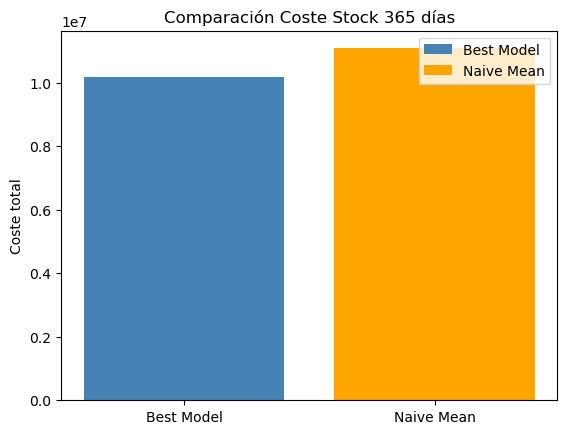

In [32]:
import matplotlib.pyplot as plt

# Calcular sumas
sum_best = df_datos_ventas['CosteStock_365_best_model'].sum()
sum_naive = df_datos_ventas['CosteStock_365_naive_mean'].sum()

plt.figure()

bars = plt.bar(
    ['Best Model', 'Naive Mean'],
    [sum_best, sum_naive],
    color=['steelblue', 'orange'],
    label=['Best Model', 'Naive Mean']
)

plt.legend()

plt.ylabel('Coste total')
plt.title('Comparación Coste Stock 365 días')
plt.savefig('imgs/comparacion_coste_stock.png', dpi=300, bbox_inches='tight')

plt.show()

In [33]:
sum_naive

11081971.245161422

In [34]:
sum_best

10170390.65919207

In [35]:
# % mejora (ahorro)
mejora_pct = (sum_naive - sum_best) / sum_naive * 100

print(f"Mejora de costes respecto a Naive: {mejora_pct:.2f}%")

Mejora de costes respecto a Naive: 8.23%


In [36]:
dinero_ahorrado_anual = sum_naive-sum_best

In [37]:
dinero_ahorrado_anual

911580.5859693512